Total customers: 2577
Churn rate: 28.09%


C:\Users\Mouni\AppData\Local\Temp\ipykernel_23972\2274023662.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=customer_df, palette='viridis')


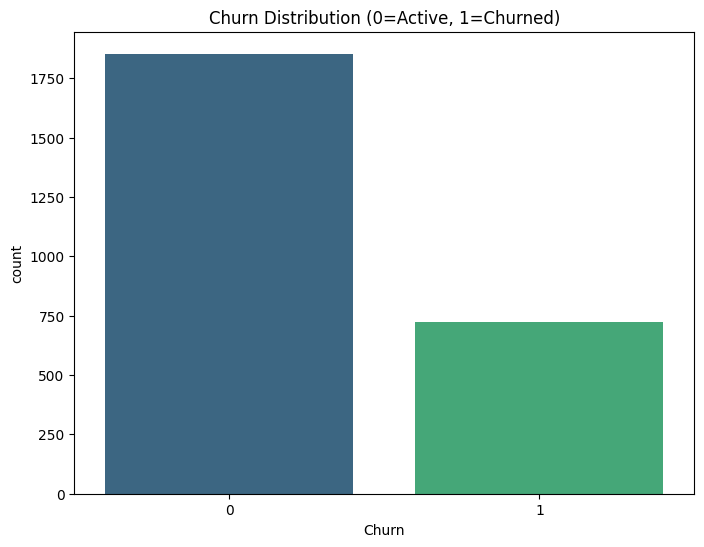

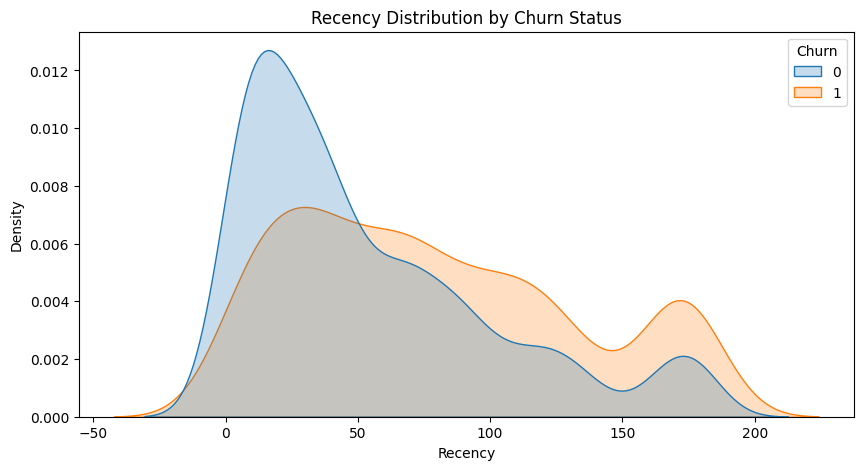

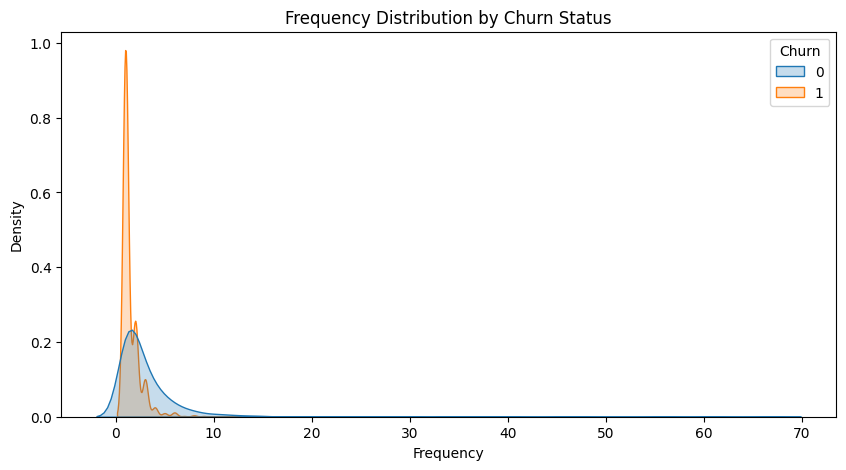

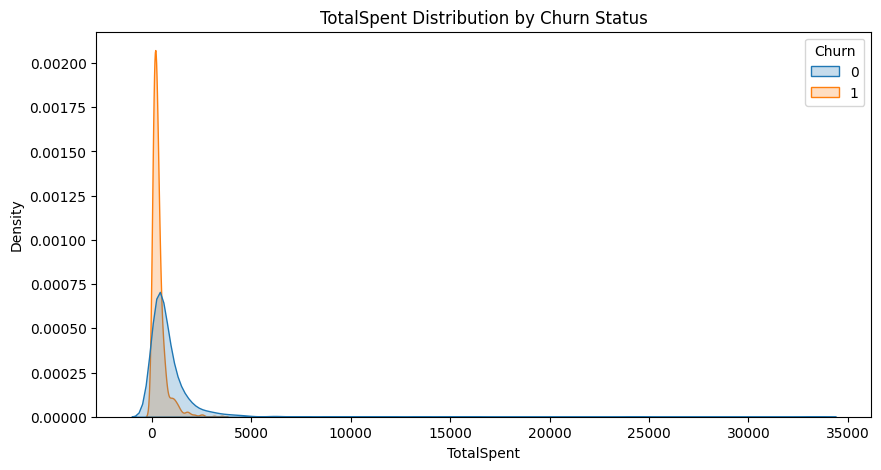

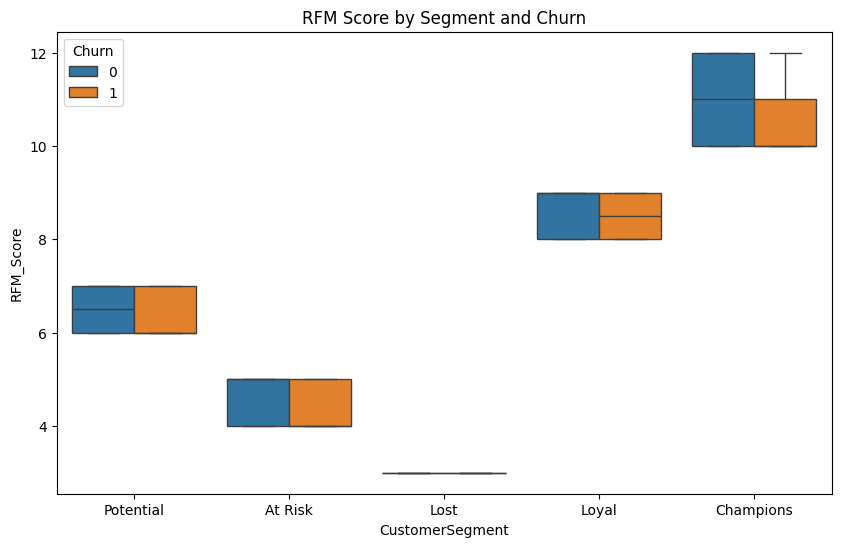

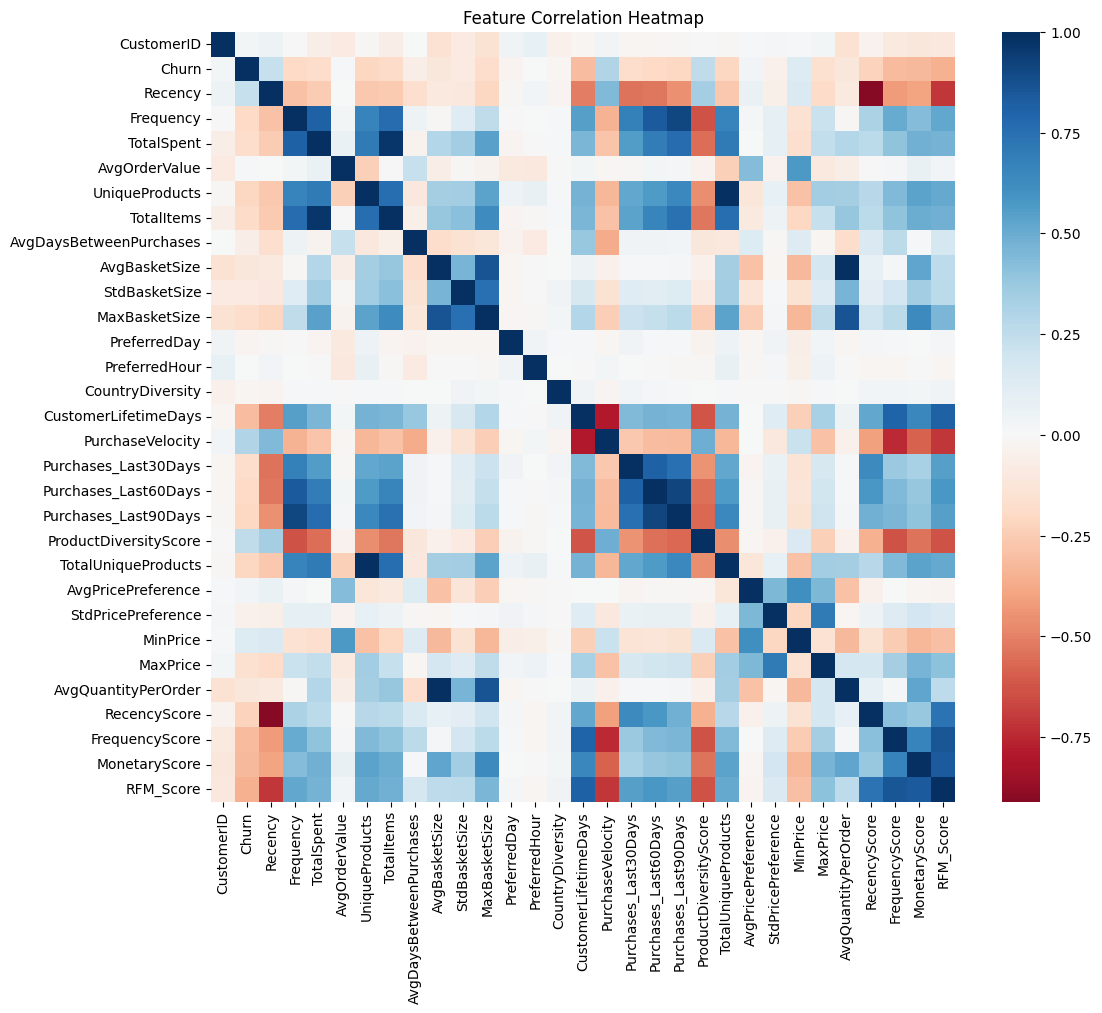

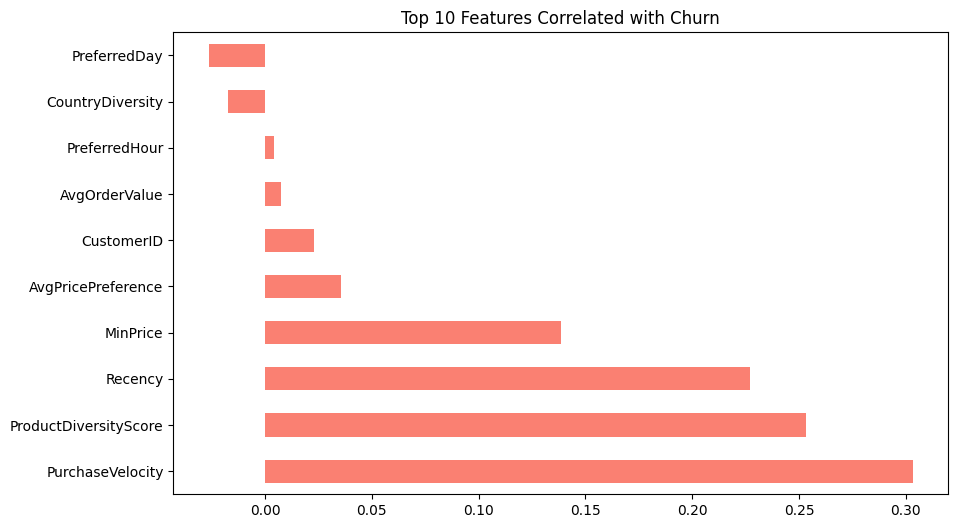

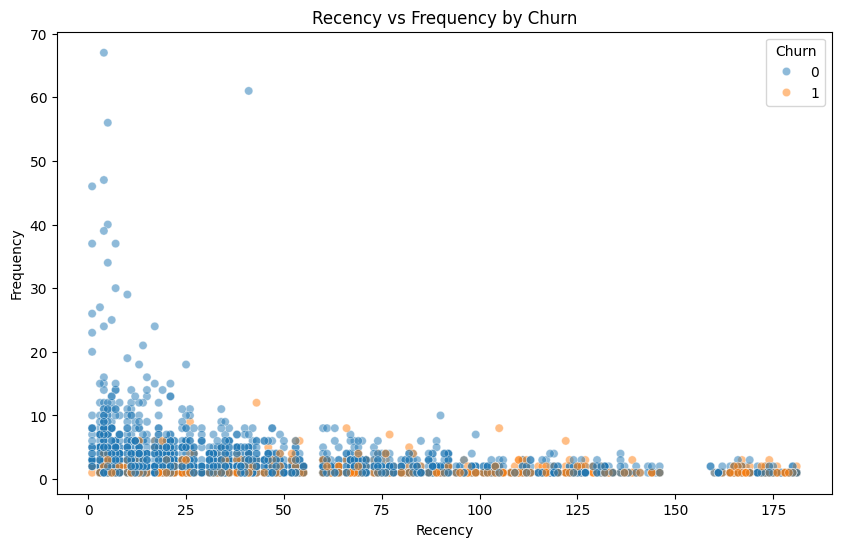

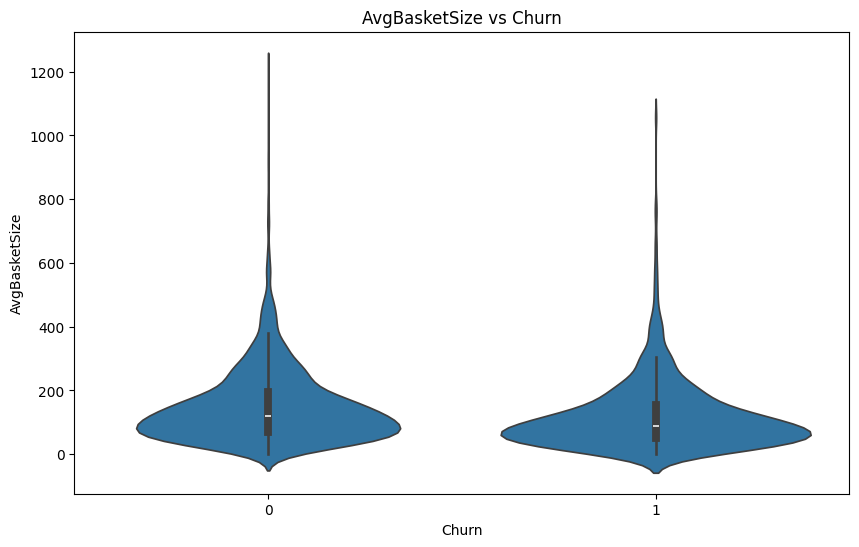

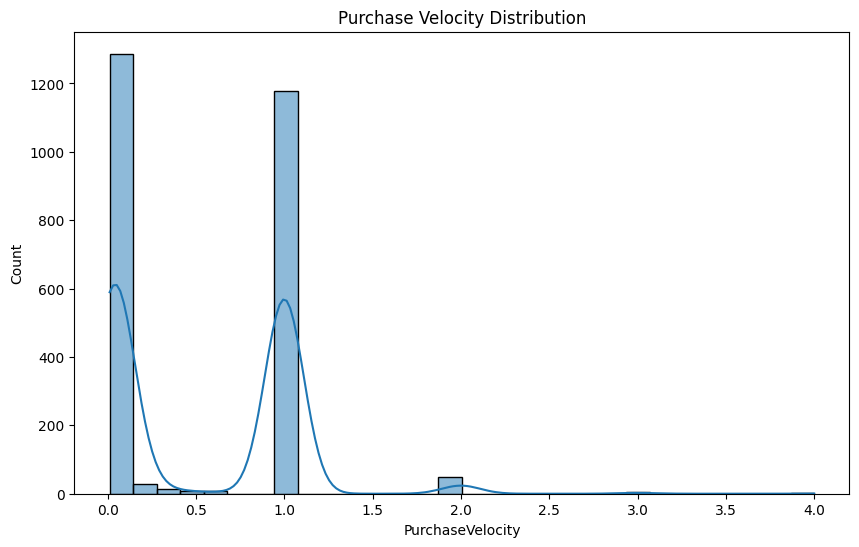

C:\Users\Mouni\AppData\Local\Temp\ipykernel_23972\2274023662.py:76: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='CustomerSegment', y='Churn', data=customer_df, ci=None)


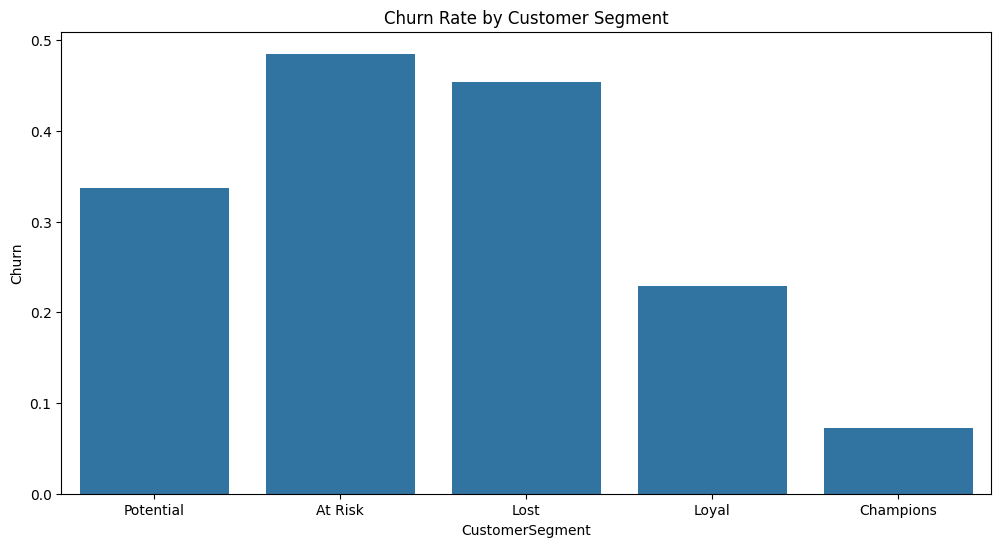

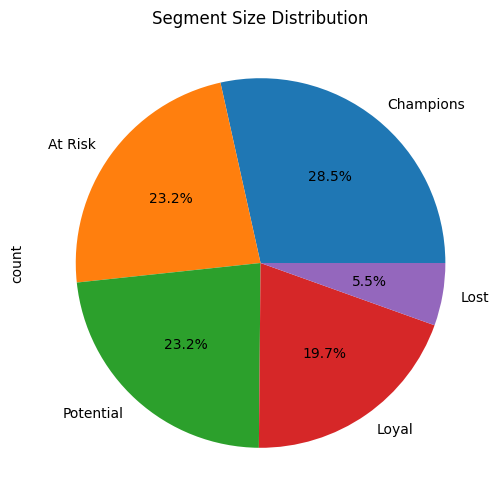

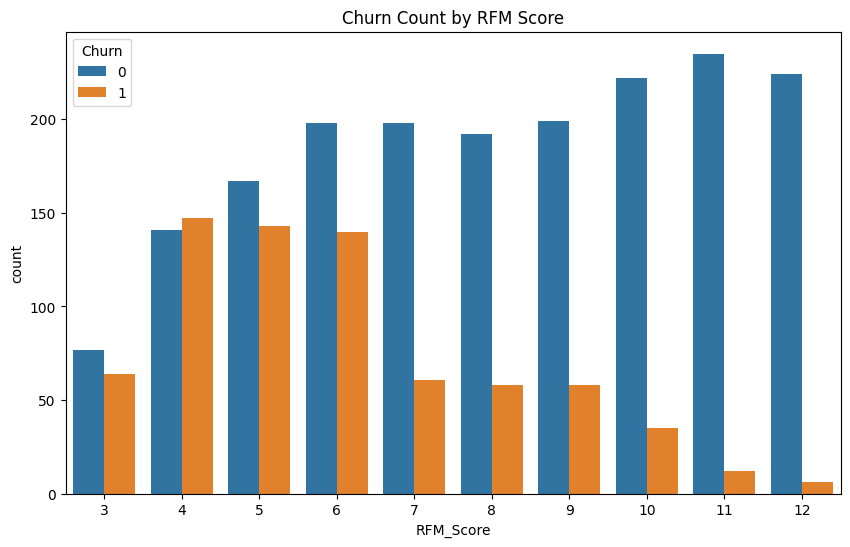

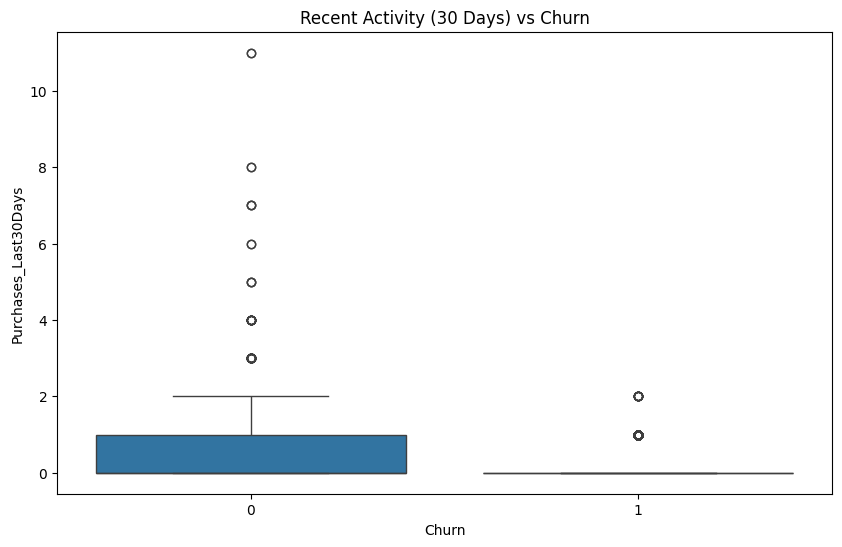

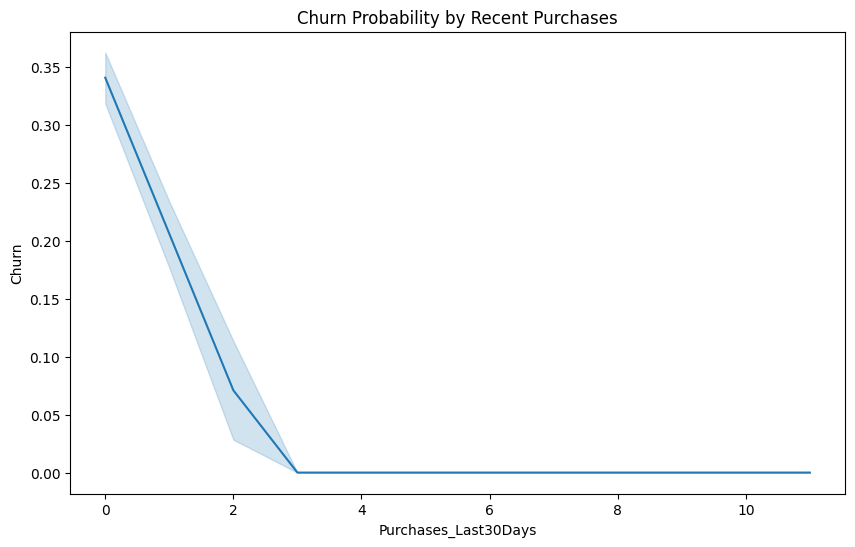


--- T-TEST RESULTS ---
✅ Recency: p=0.0000 (Significant)
✅ Frequency: p=0.0000 (Significant)
✅ TotalSpent: p=0.0000 (Significant)
❌ AvgOrderValue: p=0.6998 (Not Significant)
✅ UniqueProducts: p=0.0000 (Significant)
✅ TotalItems: p=0.0000 (Significant)
✅ AvgDaysBetweenPurchases: p=0.0021 (Significant)
✅ AvgBasketSize: p=0.0000 (Significant)
✅ StdBasketSize: p=0.0000 (Significant)
✅ MaxBasketSize: p=0.0000 (Significant)
❌ PreferredDay: p=0.1801 (Not Significant)
❌ PreferredHour: p=0.8237 (Not Significant)
❌ CountryDiversity: p=0.3767 (Not Significant)
✅ CustomerLifetimeDays: p=0.0000 (Significant)
✅ PurchaseVelocity: p=0.0000 (Significant)
✅ Purchases_Last30Days: p=0.0000 (Significant)
✅ Purchases_Last60Days: p=0.0000 (Significant)
✅ Purchases_Last90Days: p=0.0000 (Significant)
✅ ProductDiversityScore: p=0.0000 (Significant)
✅ TotalUniqueProducts: p=0.0000 (Significant)
❌ AvgPricePreference: p=0.0713 (Not Significant)
✅ StdPricePreference: p=0.0139 (Significant)
✅ MinPrice: p=0.0000 (Si

c:\Users\Mouni\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Create visualizations directory if not exists
if not os.path.exists('../visualizations'):
    os.makedirs('../visualizations')

# Load data
customer_df = pd.read_csv('../data/processed/customer_features.csv')
print(f"Total customers: {len(customer_df)}")
print(f"Churn rate: {customer_df['Churn'].mean()*100:.2f}%")

# 1. Target Variable Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Churn', data=customer_df, palette='viridis')
plt.title('Churn Distribution (0=Active, 1=Churned)')
plt.savefig('../visualizations/01_churn_distribution.png')
plt.show()

# 2-5. RFM Analysis (4 plots)
rfm_cols = ['Recency', 'Frequency', 'TotalSpent']
for i, col in enumerate(rfm_cols, 2):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=customer_df, x=col, hue='Churn', fill=True, common_norm=False)
    plt.title(f'{col} Distribution by Churn Status')
    plt.savefig(f'../visualizations/0{i}_{col}_dist.png')
    plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='CustomerSegment', y='RFM_Score', hue='Churn', data=customer_df)
plt.title('RFM Score by Segment and Churn')
plt.savefig('../visualizations/05_rfm_boxplot.png')
plt.show()

# 6-10. Correlation & Feature Analysis (5 plots)
plt.figure(figsize=(12, 10))
corr = customer_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='RdBu', center=0, annot=False)
plt.title('Feature Correlation Heatmap')
plt.savefig('../visualizations/06_heatmap.png')
plt.show()

# Top 10 Correlations with Churn
plt.figure(figsize=(10, 6))
corr['Churn'].sort_values(ascending=False)[1:11].plot(kind='barh', color='salmon')
plt.title('Top 10 Features Correlated with Churn')
plt.savefig('../visualizations/07_top_corr.png')
plt.show()

# Scatter: Recency vs Frequency
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Recency', y='Frequency', hue='Churn', data=customer_df, alpha=0.5)
plt.title('Recency vs Frequency by Churn')
plt.savefig('../visualizations/08_scatter_rf.png')
plt.show()

# Feature Distributions
plt.figure(figsize=(10, 6))
sns.violinplot(x='Churn', y='AvgBasketSize', data=customer_df)
plt.title('AvgBasketSize vs Churn')
plt.savefig('../visualizations/09_violin_basket.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(customer_df['PurchaseVelocity'], bins=30, kde=True)
plt.title('Purchase Velocity Distribution')
plt.savefig('../visualizations/10_velocity_dist.png')
plt.show()

# 11-13. Segment Analysis (3 plots)
plt.figure(figsize=(12, 6))
sns.barplot(x='CustomerSegment', y='Churn', data=customer_df, ci=None)
plt.title('Churn Rate by Customer Segment')
plt.savefig('../visualizations/11_segment_churn_rate.png')
plt.show()

plt.figure(figsize=(10, 6))
customer_df['CustomerSegment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Segment Size Distribution')
plt.savefig('../visualizations/12_segment_pie.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='RFM_Score', hue='Churn', data=customer_df)
plt.title('Churn Count by RFM Score')
plt.savefig('../visualizations/13_rfm_score_churn.png')
plt.show()

# 14-15. Temporal Patterns (2 plots)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='Purchases_Last30Days', data=customer_df)
plt.title('Recent Activity (30 Days) vs Churn')
plt.savefig('../visualizations/14_recent_30.png')
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(x='Purchases_Last30Days', y='Churn', data=customer_df)
plt.title('Churn Probability by Recent Purchases')
plt.savefig('../visualizations/15_prob_line.png')
plt.show()

# --- Statistical Tests ---
print("\n--- T-TEST RESULTS ---")
numerical_cols = customer_df.select_dtypes(include=[np.number]).columns
significant_features = []

for col in numerical_cols:
    if col not in ['CustomerID', 'Churn']:
        churned = customer_df[customer_df['Churn'] == 1][col]
        active = customer_df[customer_df['Churn'] == 0][col]
        
        # Drop NaNs for test
        t_stat, p_val = stats.ttest_ind(churned.dropna(), active.dropna())
        
        if p_val < 0.05:
            significant_features.append(col)
            print(f"✅ {col}: p={p_val:.4f} (Significant)")
        else:
            print(f"❌ {col}: p={p_val:.4f} (Not Significant)")

print(f"\nTotal Significant Features found: {len(significant_features)}")